# Loan Default Risk - Data Preprocessing and Predictive Modelling
Python preprocessing pipeline: missing value treatment, outlier capping, feature engineering, date processing, and logistic regression modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data/finance_loan_default_dataset_2026.csv")

# Basic info
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (50000, 16)

Column names:
['customer_id', 'age', 'gender', 'marital_status', 'education', 'region', 'employment_status', 'annual_income', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term_months', 'dti_ratio', 'loan_purpose', 'loan_issue_date', 'loan_default']

First 5 rows:


,customer_id,age,gender,marital_status,education,region,employment_status,annual_income,credit_score,loan_amount,interest_rate,loan_term_months,dti_ratio,loan_purpose,loan_issue_date,loan_default
0,L000001,19,Male,Divorced,Master,South,Self-employed,45199.0,631.0,16659.0,10.29,36,49.40,Debt consolidation,2018-03-04,1
1,L000002,24,Other,Divorced,Bachelor,North,Unemployed,13607.0,546.0,1000.0,14.66,24,1.00,Holiday,2021-05-06,0
2,L000003,44,Male,Married,Secondary,East,Unemployed,8269.0,523.0,6240.0,17.38,48,61.95,Business,2023-05-06,1
3,L000004,31,Male,Divorced,Diploma,South,Employed,37921.0,614.0,8302.0,10.48,36,24.60,Education,2018-03-28,0
4,L000005,31,Female,Single,Master,West,Student,44252.0,664.0,22745.0,7.34,12,43.60,Business,2022-02-25,0


## 1. Missing Value Analysis

In [2]:
# Check missing values in the three key columns
missing_before = df[['annual_income', 'credit_score', 'loan_amount']].isnull().sum()
missing_pct_before = (missing_before / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_before,
    'Missing %': missing_pct_before
})

print("=== Missing Values BEFORE Treatment ===")
print(missing_summary)

=== Missing Values BEFORE Treatment ===
               Missing Count  Missing %
annual_income           1500        3.0
credit_score            2000        4.0
loan_amount             1000        2.0


In [3]:
# Apply median imputation
median_income = df['annual_income'].median()
median_credit = df['credit_score'].median()
median_loan = df['loan_amount'].median()

print("Median values used for imputation:")
print(f"annual_income median: {median_income}")
print(f"credit_score median: {median_credit}")
print(f"loan_amount median: {median_loan}")

df['annual_income'] = df['annual_income'].fillna(median_income)
df['credit_score'] = df['credit_score'].fillna(median_credit)
df['loan_amount'] = df['loan_amount'].fillna(median_loan)

# Check missing values AFTER treatment
missing_after = df[['annual_income', 'credit_score', 'loan_amount']].isnull().sum()

print("\n=== Missing Values AFTER Treatment ===")
print(missing_after)

Median values used for imputation:
annual_income median: 48133.0
credit_score median: 619.0
loan_amount median: 14872.0

=== Missing Values AFTER Treatment ===
annual_income    0
credit_score     0
loan_amount      0
dtype: int64


## 2. Outlier Analysis (IQR Method)

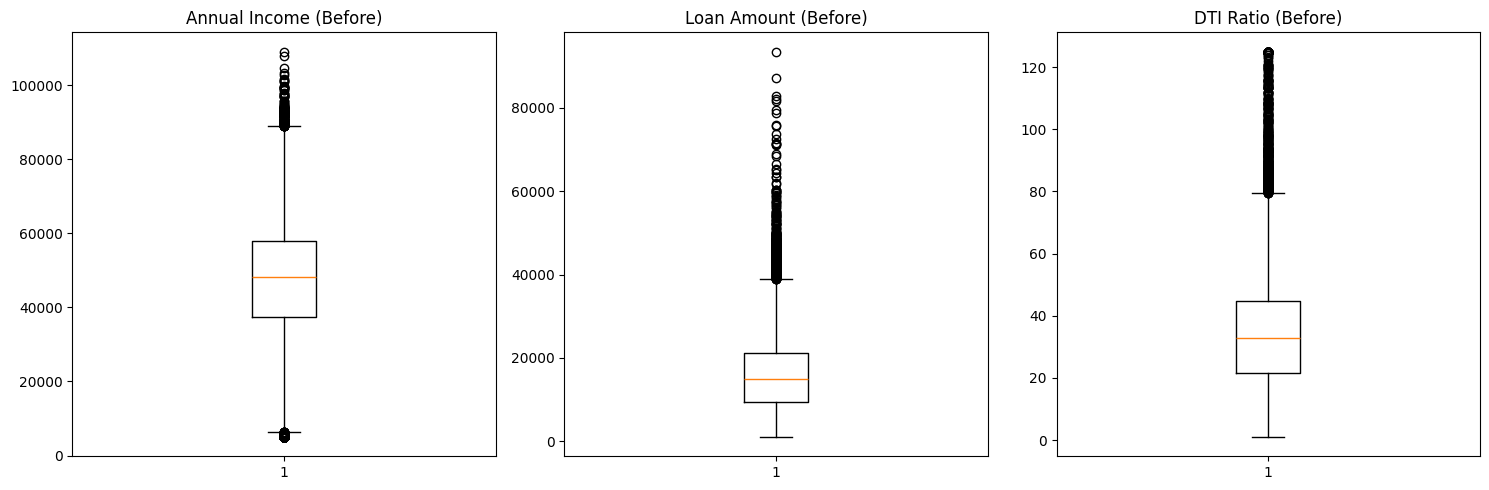

In [4]:
# Boxplots BEFORE outlier treatment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(df['annual_income'])
axes[0].set_title('Annual Income (Before)')

axes[1].boxplot(df['loan_amount'])
axes[1].set_title('Loan Amount (Before)')

axes[2].boxplot(df['dti_ratio'])
axes[2].set_title('DTI Ratio (Before)')

plt.tight_layout()
plt.savefig('charts/boxplots_before.png', dpi=150)
plt.show()

In [5]:
# Function to cap outliers using IQR method
def cap_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)).sum()

    dataframe[column] = dataframe[column].clip(lower=lower_bound, upper=upper_bound)

    print(f"{column}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"Lower bound={lower_bound:.2f}, Upper bound={upper_bound:.2f}")
    print(f"Outliers capped: {outliers_count}")
    print()

    return dataframe

# Apply to the three columns
for col in ['annual_income', 'loan_amount', 'dti_ratio']:
    df = cap_outliers_iqr(df, col)

annual_income: Q1=37323.50, Q3=57950.25, IQR=20626.75
Lower bound=6383.38, Upper bound=88890.38
Outliers capped: 508

loan_amount: Q1=9338.75, Q3=21196.75, IQR=11858.00
Lower bound=-8448.25, Upper bound=38983.75
Outliers capped: 680

dti_ratio: Q1=21.52, Q3=44.73, IQR=23.21
Lower bound=-13.29, Upper bound=79.54
Outliers capped: 496



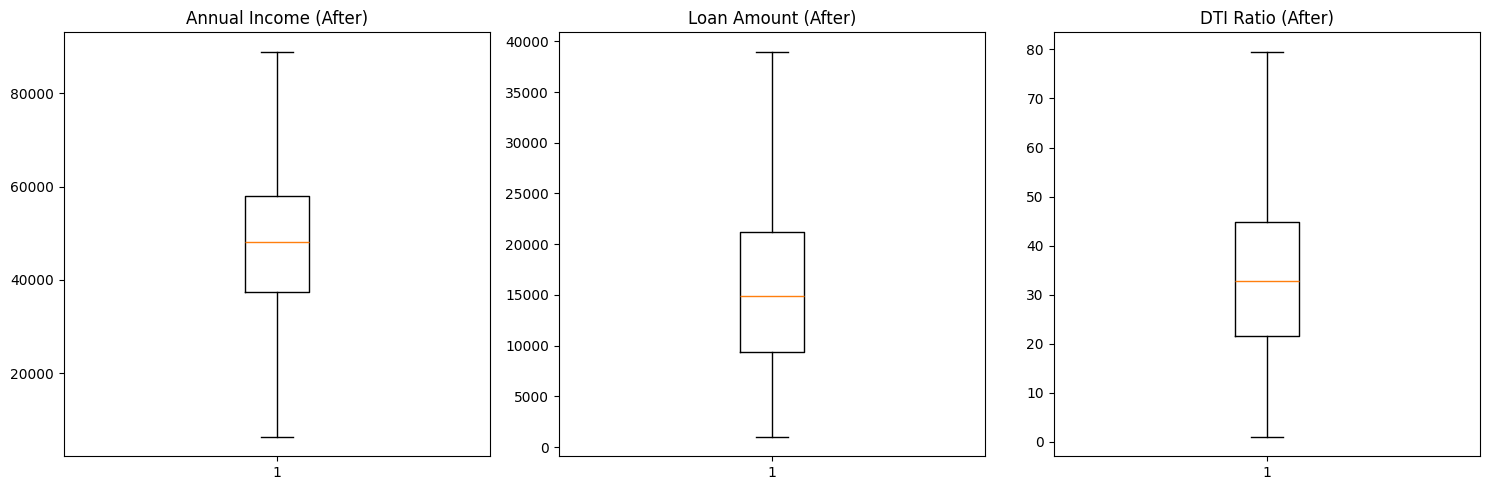

In [6]:
# Boxplots AFTER outlier treatment
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(df['annual_income'])
axes[0].set_title('Annual Income (After)')

axes[1].boxplot(df['loan_amount'])
axes[1].set_title('Loan Amount (After)')

axes[2].boxplot(df['dti_ratio'])
axes[2].set_title('DTI Ratio (After)')

plt.tight_layout()
plt.savefig('charts/boxplots_after.png', dpi=150)
plt.show()

## 3. Feature Engineering

In [7]:
# Feature 1: Income_Band (Low / Medium / High)
def income_band(income):
    if income < 30000:
        return 'Low'
    elif income <= 60000:
        return 'Medium'
    else:
        return 'High'

df['Income_Band'] = df['annual_income'].apply(income_band)

# Feature 2: Credit_Risk (Poor / Fair / Good / Excellent)
def credit_risk(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Fair'
    elif score < 740:
        return 'Good'
    else:
        return 'Excellent'

df['Credit_Risk'] = df['credit_score'].apply(credit_risk)

# Check the new features
print("=== Income_Band distribution ===")
print(df['Income_Band'].value_counts())

print("\n=== Credit_Risk distribution ===")
print(df['Credit_Risk'].value_counts())

print("\nSample rows with new features:")
df[['annual_income', 'Income_Band', 'credit_score', 'Credit_Risk']].head(10)

=== Income_Band distribution ===
Income_Band
Medium    32434
High      10506
Low        7060
Name: count, dtype: int64

=== Credit_Risk distribution ===
Credit_Risk
Fair         28125
Poor         12521
Good          8377
Excellent      977
Name: count, dtype: int64

Sample rows with new features:


,annual_income,Income_Band,credit_score,Credit_Risk
0,45199.0,Medium,631.0,Fair
1,13607.0,Low,546.0,Poor
2,8269.0,Low,523.0,Poor
3,37921.0,Medium,614.0,Fair
4,44252.0,Medium,664.0,Fair
5,66890.0,High,664.0,Fair
6,24718.0,Low,534.0,Poor
7,54432.0,Medium,603.0,Fair
8,52564.0,Medium,630.0,Fair
9,30294.0,Medium,666.0,Fair


## 4. Date Processing

Data type after conversion: datetime64[us]

Loan_Year distribution:
Loan_Year
2018    7043
2019    7105
2020    7148
2021    7105
2022    7206
2023    7190
2024    7203
Name: count, dtype: int64

Default rate (%) by year:
Loan_Year
2018    25.03
2019    25.18
2020    24.40
2021    24.86
2022    24.23
2023    25.42
2024    24.68
Name: loan_default, dtype: float64


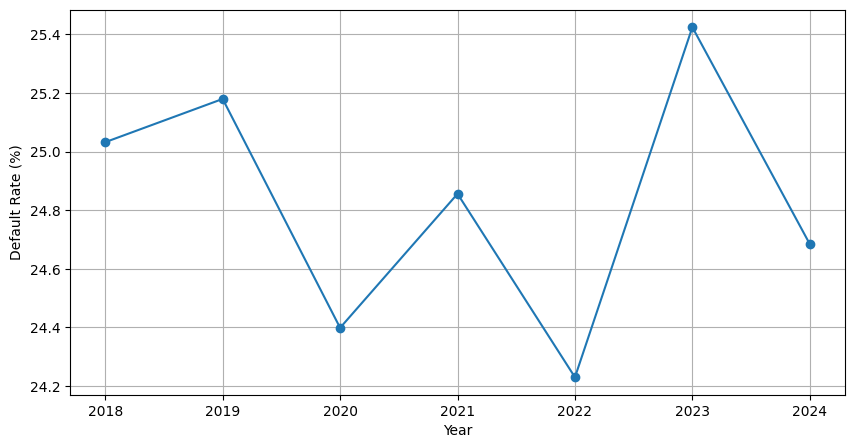

In [8]:
# Convert loan_issue_date to datetime
df['loan_issue_date'] = pd.to_datetime(df['loan_issue_date'])

# Extract Loan_Year
df['Loan_Year'] = df['loan_issue_date'].dt.year

print("Data type after conversion:", df['loan_issue_date'].dtype)
print("\nLoan_Year distribution:")
print(df['Loan_Year'].value_counts().sort_index())

# Default rate by year
default_by_year = df.groupby('Loan_Year')['loan_default'].mean() * 100
print("\nDefault rate (%) by year:")
print(default_by_year.round(2))

# Plot trend
plt.figure(figsize=(10, 5))
default_by_year.plot(kind='line', marker='o')
plt.xlabel('Year')
plt.ylabel('Default Rate (%)')
plt.grid(True)
plt.savefig('charts/default_trend_by_year.png', dpi=150)
plt.show()

In [9]:
# Save cleaned dataset for use in R
df.to_csv('data/cleaned_loan_data.csv', index=False)
print("Cleaned dataset saved as 'data/cleaned_loan_data.csv'")
print("Final shape:", df.shape)
print("\nFinal columns:", df.columns.tolist())

Cleaned dataset saved as 'data/cleaned_loan_data.csv'
Final shape: (50000, 19)

Final columns: ['customer_id', 'age', 'gender', 'marital_status', 'education', 'region', 'employment_status', 'annual_income', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term_months', 'dti_ratio', 'loan_purpose', 'loan_issue_date', 'loan_default', 'Income_Band', 'Credit_Risk', 'Loan_Year']


## 5. Predictive Modelling (Logistic Regression)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                              recall_score, f1_score, confusion_matrix, classification_report)

# Select features for modeling
features = ['age', 'annual_income', 'credit_score', 'loan_amount', 'interest_rate',
            'loan_term_months', 'dti_ratio', 'gender', 'marital_status', 'education',
            'region', 'employment_status', 'loan_purpose', 'Income_Band', 'Credit_Risk']

X = df[features].copy()
y = df['loan_default']

# Encode categorical variables
categorical_cols = ['gender', 'marital_status', 'education', 'region',
                     'employment_status', 'loan_purpose', 'Income_Band', 'Credit_Risk']

le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

print("Features used:", features)
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Features used: ['age', 'annual_income', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term_months', 'dti_ratio', 'gender', 'marital_status', 'education', 'region', 'employment_status', 'loan_purpose', 'Income_Band', 'Credit_Risk']

Shape of X: (50000, 15)
Shape of y: (50000,)


In [11]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nDefault rate in training set:", y_train.mean().round(4))
print("Default rate in testing set:", y_test.mean().round(4))

Training set size: (40000, 15)
Testing set size: (10000, 15)

Default rate in training set: 0.2483
Default rate in testing set: 0.2483


In [12]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression with scaled data
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

print("Model trained successfully with scaled features!")
print("\nFeature Coefficients:")
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model_lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df)

Model trained successfully with scaled features!

Feature Coefficients:
              Feature  Coefficient
2        credit_score    -0.578751
4       interest_rate     0.485830
6           dti_ratio     0.460633
11  employment_status     0.182367
1       annual_income    -0.147559
13        Income_Band    -0.073670
10             region     0.030213
5    loan_term_months     0.027325
3         loan_amount     0.021330
12       loan_purpose    -0.014005
8      marital_status    -0.012171
0                 age     0.010109
14        Credit_Risk    -0.007640
7              gender    -0.005827
9           education     0.005619


## 6. Model Evaluation

In [13]:
# Make predictions on test set
y_pred = model_lr.predict(X_test_scaled)
y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Model Evaluation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Model Evaluation Metrics ===
Accuracy:  0.7973
ROC-AUC:   0.7883
Precision: 0.6707
Recall:    0.3609
F1-Score:  0.4692

=== Confusion Matrix ===
[[7077  440]
 [1587  896]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.82      0.94      0.87      7517
           1       0.67      0.36      0.47      2483

    accuracy                           0.80     10000
   macro avg       0.74      0.65      0.67     10000
weighted avg       0.78      0.80      0.77     10000



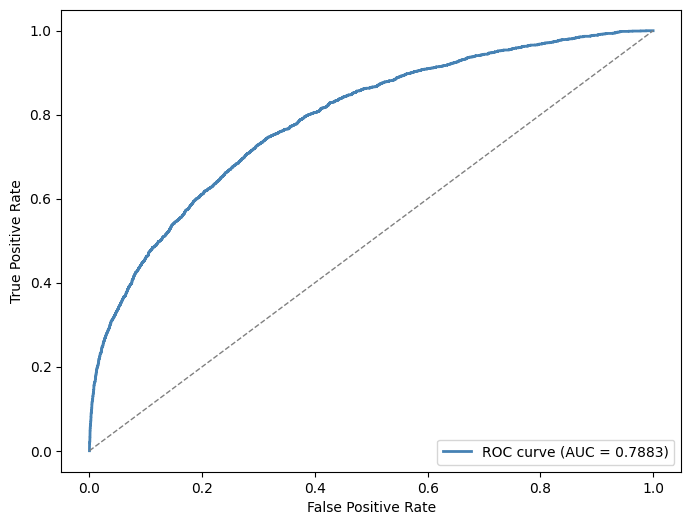

In [14]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.savefig('charts/roc_curve.png', dpi=300)
plt.show()